# Imports

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Bilayer Graphene

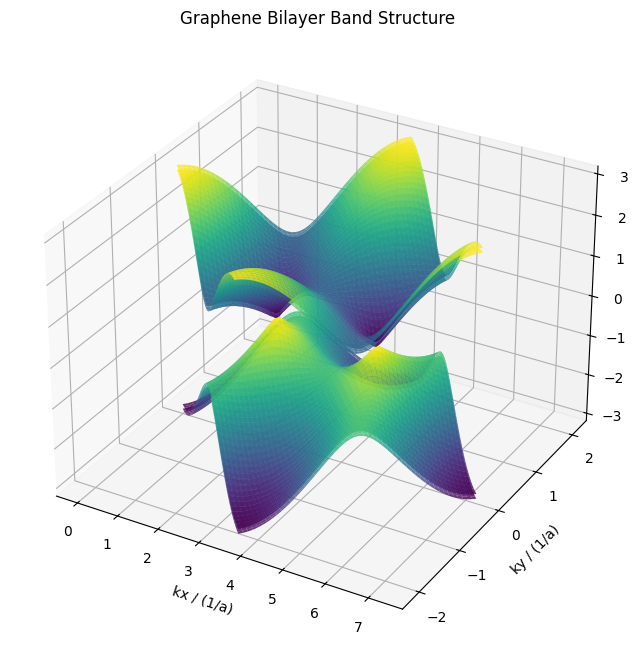

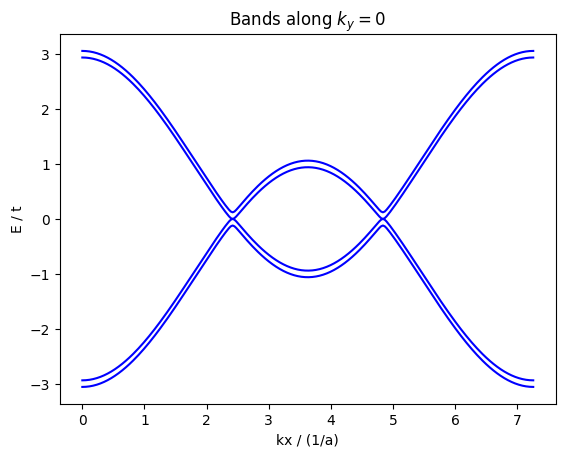

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Ebar = 0
Delta = 0.0
tperp = 0.12

# FBZ Resolution
L = 250

# Reciprocal lattice vectors
b1 = 4 * np.pi / 3 * np.array([np.sqrt(3)/2, 1/2])
b2 = 4 * np.pi / 3 * np.array([-np.sqrt(3)/2, 1/2]) * (-1)

# Create the meshgrid for k-vector indexes
m1 = np.linspace(0, 1, L)
m2 = np.linspace(0, 1, L)
M1, M2 = np.meshgrid(m1, m2)

# Map the fractional meshgrid to Cartesian kx, ky space
mesh_kx = M1 * b1[0] + M2 * b2[0]
mesh_ky = M1 * b1[1] + M2 * b2[1]

# Calculate the function f^2
f_k_squared = 3 + 2 * np.cos(np.sqrt(3) * mesh_kx) + 4 * np.cos(np.sqrt(3)/2 * mesh_kx) * np.cos(3/2 * mesh_ky)

# Compute the bands
E_conduct_plus = + tperp / 2 * (np.sqrt(1 + 4 / (tperp**2) * f_k_squared) + 1)
E_conduct_minu = + tperp / 2 * (np.sqrt(1 + 4 / (tperp**2) * f_k_squared) - 1)
E_valence_plus = - tperp / 2 * (np.sqrt(1 + 4 / (tperp**2) * f_k_squared) + 1)
E_valence_minu = - tperp / 2 * (np.sqrt(1 + 4 / (tperp**2) * f_k_squared) - 1)

# Plot Surfaces
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 8))

surf_cp = ax.plot_surface(mesh_kx, mesh_ky, E_conduct_plus, cmap='viridis', linewidth=0, alpha=0.8)
surf_cm = ax.plot_surface(mesh_kx, mesh_ky, E_conduct_minu, cmap='viridis', linewidth=0, alpha=0.8)
surf_vp = ax.plot_surface(mesh_kx, mesh_ky, E_valence_plus, cmap='viridis', linewidth=0, alpha=0.8)
surf_vm = ax.plot_surface(mesh_kx, mesh_ky, E_valence_minu, cmap='viridis', linewidth=0, alpha=0.8)

ax.set_xlabel('kx / (1/a)')
ax.set_ylabel('ky / (1/a)')
ax.set_zlabel('E / t')
ax.set_title('Graphene Bilayer Band Structure')

plt.show()


# Plot cut along ky = 0
mask = np.argwhere(mesh_ky == np.min(np.abs(mesh_ky)))
kkx = np.array([mesh_kx[item[0], item[1]] for item in mask])
f_k_squared = np.array([3 + 2 * np.cos(np.sqrt(3) * mesh_kx[item[0], item[1]]) + 4 * np.cos(np.sqrt(3)/2 * mesh_kx[item[0], item[1]]) * np.cos(3/2 * mesh_ky[item[0], item[1]]) for item in mask])

# Compute the bands
E_conduct_plus = + tperp / 2 * (np.sqrt(1 + 4 / (tperp**2) * f_k_squared) + 1)
E_conduct_minu = + tperp / 2 * (np.sqrt(1 + 4 / (tperp**2) * f_k_squared) - 1)
E_valence_plus = - tperp / 2 * (np.sqrt(1 + 4 / (tperp**2) * f_k_squared) + 1)
E_valence_minu = - tperp / 2 * (np.sqrt(1 + 4 / (tperp**2) * f_k_squared) - 1)

plt.title("Bands along $k_y = 0$")
plt.plot(kkx, E_conduct_plus, c="blue", label="Conduction Band")
plt.plot(kkx, E_conduct_minu, c="blue", label="Valence Band")
plt.plot(kkx, E_valence_plus, c="blue", label="Conduction Band")
plt.plot(kkx, E_valence_minu, c="blue", label="Valence Band")
plt.xlabel("kx / (1/a)")
plt.ylabel("E / t")
plt.show()

# Single-Layer Graphene

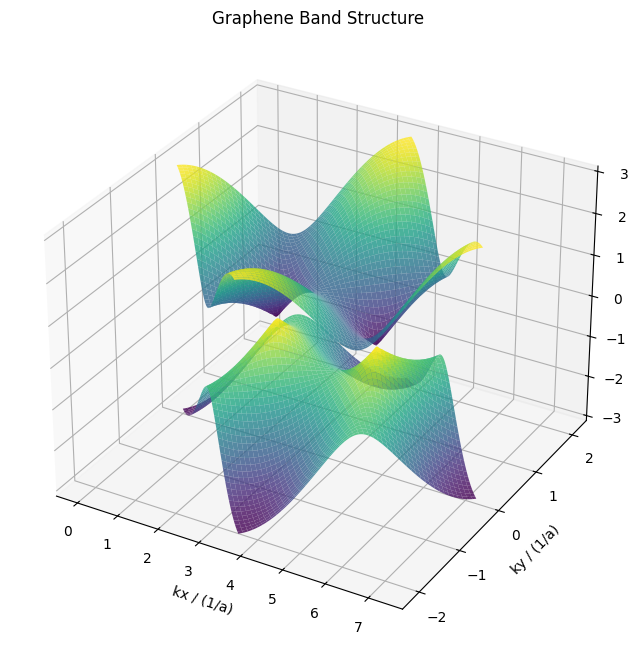

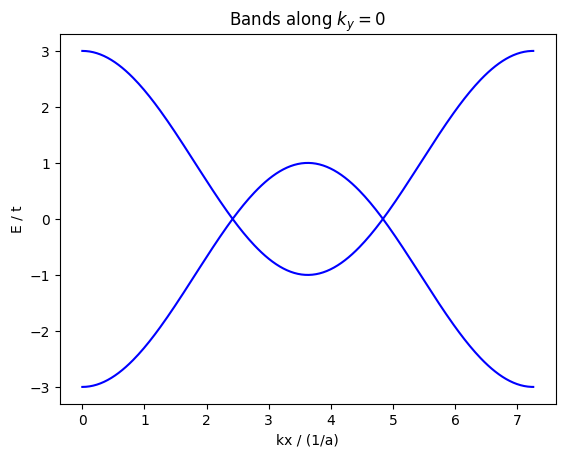

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Ebar = 0
Delta = 0.0

# FBZ Resolution
L = 250

# Reciprocal lattice vectors
b1 = 4 * np.pi / 3 * np.array([np.sqrt(3)/2, 1/2])
b2 = 4 * np.pi / 3 * np.array([-np.sqrt(3)/2, 1/2]) * (-1)

# Create the meshgrid for k-vector indexes
m1 = np.linspace(0, 1, L)
m2 = np.linspace(0, 1, L)
M1, M2 = np.meshgrid(m1, m2)

# Map the fractional meshgrid to Cartesian kx, ky space
mesh_kx = M1 * b1[0] + M2 * b2[0]
mesh_ky = M1 * b1[1] + M2 * b2[1]

# Calculate the function f^2
f_k_squared = 3 + 2 * np.cos(np.sqrt(3) * mesh_kx) + 4 * np.cos(np.sqrt(3)/2 * mesh_kx) * np.cos(3/2 * mesh_ky)

# Compute the bands
E_conduct = Ebar + 0.5 * np.sqrt(Delta**2 + 4 * f_k_squared)
E_valence = Ebar - 0.5 * np.sqrt(Delta**2 + 4 * f_k_squared)

# Plot Surfaces
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 8))

surf_c = ax.plot_surface(mesh_kx, mesh_ky, E_conduct, cmap='viridis', linewidth=0, alpha=0.8)
surf_v = ax.plot_surface(mesh_kx, mesh_ky, E_valence, cmap='viridis', linewidth=0, alpha=0.8)

ax.set_xlabel('kx / (1/a)')
ax.set_ylabel('ky / (1/a)')
ax.set_zlabel('E / t')
ax.set_title('Graphene Band Structure')

plt.show()


# Plot cut along ky = 0
mask = np.argwhere(mesh_ky == np.min(np.abs(mesh_ky)))
kkx = np.array([mesh_kx[item[0], item[1]] for item in mask])
f_k_squared = np.array([3 + 2 * np.cos(np.sqrt(3) * mesh_kx[item[0], item[1]]) + 4 * np.cos(np.sqrt(3)/2 * mesh_kx[item[0], item[1]]) * np.cos(3/2 * mesh_ky[item[0], item[1]]) for item in mask])

# Compute the bands
E_conduct = Ebar + 0.5 * np.sqrt(Delta**2 + 4 * f_k_squared)
E_valence = Ebar - 0.5 * np.sqrt(Delta**2 + 4 * f_k_squared)

plt.title("Bands along $k_y = 0$")
plt.plot(kkx, E_conduct, c="blue", label="Conduction Band")
plt.plot(kkx, E_valence, c="blue", label="Valence Band")
plt.xlabel("kx / (1/a)")
plt.ylabel("E / t")
plt.show()